In [28]:
import seaborn as sns
import pandas as pd
import json
import matplotlib.pyplot as plt
#sns.set(rc={'figure.figsize':(12,12)})
sns.set_style("white")


In [46]:
def read_features(fn="ai_images.json", img_type="ai"):
    df = pd.read_json(fn)

    feature_cols = ['color_fulness', 'tone', 'saturation', 'si', 'cpbd', 'blur_stength']

    # Reshape data to long format
    df_long = df.melt(value_vars=feature_cols, 
                      var_name='feature', 
                      value_name='value')
    df_long["type"] = img_type
    return df_long

df_long = read_features("ai_images.json", img_type="ai")
df_long

,feature,value,type
0,color_fulness,138.946248,ai
1,color_fulness,157.931652,ai
2,color_fulness,163.721937,ai
3,color_fulness,133.427117,ai
4,color_fulness,151.474763,ai
...,...,...,...
319,blur_stength,0.285599,ai
320,blur_stength,0.423365,ai
321,blur_stength,0.372672,ai
322,blur_stength,0.398411,ai


In [50]:

df_long = pd.concat([read_features("real_images.json", img_type="real"), df_long], ignore_index=True).sort_values(by="type")
df_long

,feature,value,type
971,blur_stength,0.397774,ai
750,tone,0.901382,ai
751,tone,0.905265,ai
752,tone,0.878321,ai
753,tone,0.812368,ai
...,...,...,...
329,color_fulness,88.525819,real
330,color_fulness,131.269444,real
331,color_fulness,130.668508,real
303,blur_stength,0.323013,real


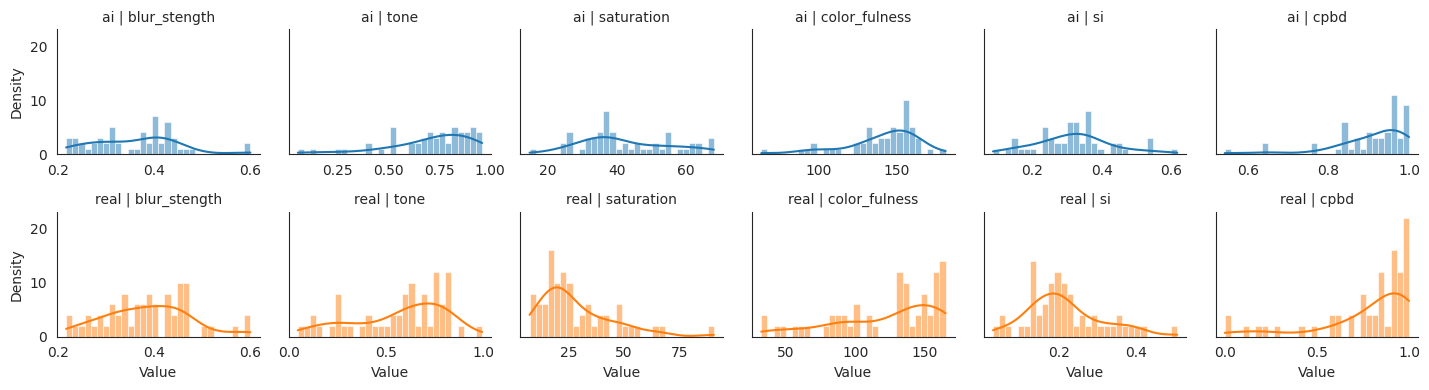

In [52]:
# Create FacetGrid
g = sns.FacetGrid(df_long, col='feature', row="type", hue="type", palette=sns.color_palette()[0:2],
                  sharex=False, sharey=True, height=2, aspect=1.2)
g.map(sns.histplot, 'value', kde=True, bins=30)
#g.set_titles('{col_name}')
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels('Value', 'Density')
g.tight_layout()

plt.savefig('feature_distributions.pdf', bbox_inches='tight')
plt.show()

<Axes: xlabel='value', ylabel='feature'>

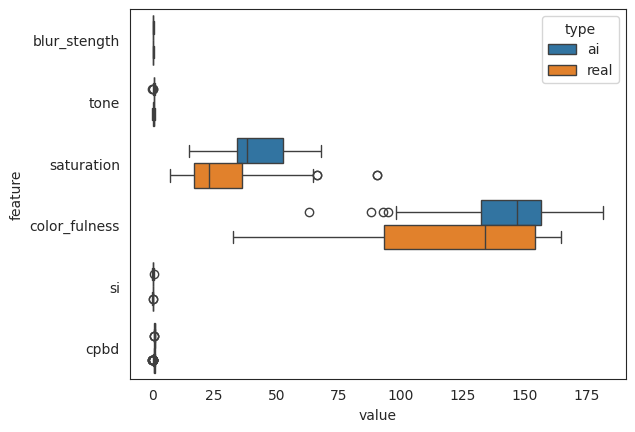

In [53]:
sns.boxplot(y="feature", x="value", hue="type", data=df_long)

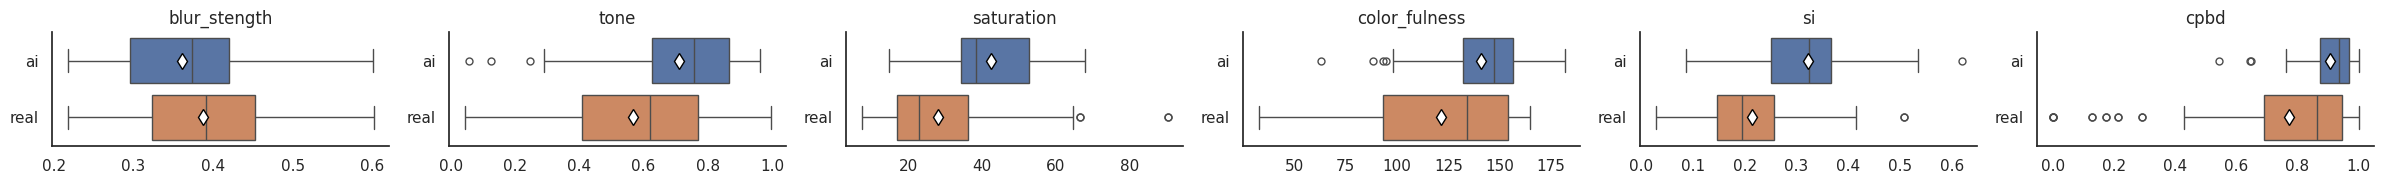

In [68]:
sns.set(rc={'figure.figsize':(8,1.5)})
sns.set_style("white")

g = sns.catplot(
    data=df_long, x="value", y="type", col="feature", hue="type", kind="box", sharey=False,sharex=False,
    showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'},
    height=2,  
    aspect=2 
)

g.set_titles("{col_name}")  # Clean titles showing feature names
g.set_axis_labels("", "")  # Set axis labels (empty x-label if redundant)
g.tight_layout() 
g.savefig('feature_analysis.pdf', bbox_inches='tight')